In [ ]:
# Install the Google Generative AI SDK
!pip install -q google-generativeai

In [ ]:
# Set the Google API key as an environment variable
import os
os.environ['GOOGLE_API_KEY'] = 'ENTER_API_KEY'

In [ ]:
# Import necessary modules for working with the Gemini API, image processing, and displaying results
from google import genai
from google.genai import types
from PIL import Image, ImageDraw, ImageFont
import json
from IPython.display import display

In [ ]:
# Initialize a Gemini client instance for interacting with the API
client = genai.Client()

# Image Understanding Capability

Gemini models are built to multimodel from the ground up, unlocking a wide range of image processing and computer vision tasks, without having to train specialized ML models.

### Think of it like giving the AI eyes - it can look at a picture and:

1. Describe it in words (image captioning)

2. Answer questions about it (visual Q&A)

3. Find & locate objects, image labelling

4. Read text in images (OCR)

5. Compare images (find differences, similarities)

6. Extract data (like reading numbers, charts, forms)

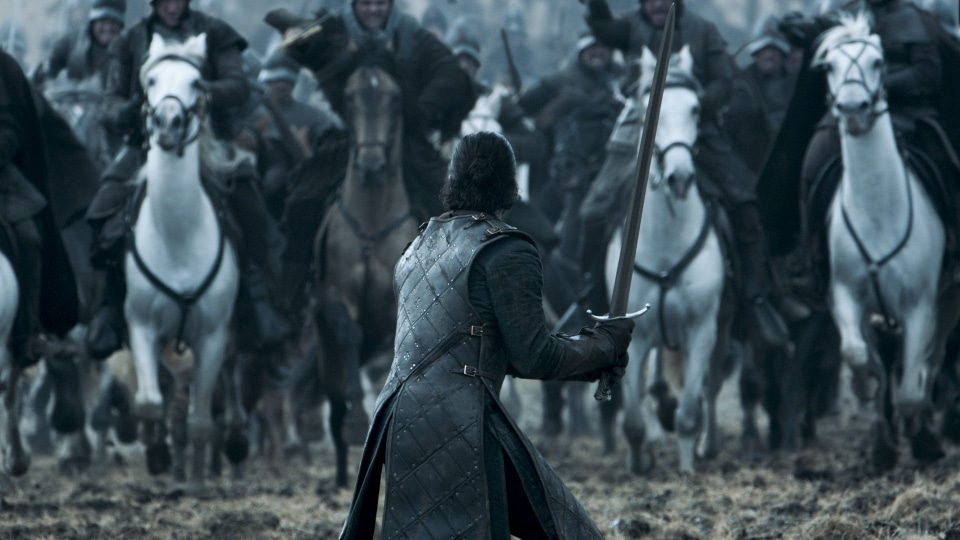

In [ ]:
# Open and display the first Game of Thrones image
image_1 = Image.open("/content/GOT_1.jpg")
image_1

In [ ]:
# Generate a one-sentence description of the given image using the Gemini model
prompt_1 = "Describe this image in 1 sentence"

response_1 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[image_1, prompt_1]  # Provide the image and the description prompt
)

# Print the generated one-sentence image description
print(response_1.text)

A lone warrior, seen from behind with a sword, stands defiantly as a large cavalry force charges directly at them across a desolate battlefield.


In [ ]:
# Generate a suitable caption for the given image using the Gemini model
prompt_2 = "Give an caption for the image"

response_2 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[image_1, prompt_2]  # Provide the image and the caption prompt
)

# Print the generated image caption
print(response_2.text)

Here are a few caption options for the image:

**General/Descriptive:**

*   A lone warrior, sword in hand, stands firm against an oncoming cavalry charge.
*   One figure stands defiantly as a horde of horsemen gallops towards them.
*   Facing overwhelming odds, a warrior prepares for battle.
*   A powerful depiction of solitary courage amidst a chaotic battlefield.
*   A warrior holds their ground as a massive cavalry charge bears down upon them.

**Evocative/Dramatic:**

*   The ultimate test of courage: one against many.
*   A moment of solitary defiance before the storm breaks.
*   Against impossible odds, a single blade holds the line.
*   When retreat is not an option, a warrior makes a final stand.
*   The calm before the thunderous clash.

**Short & Punchy:**

*   Facing the charge.
*   The last stand.
*   Defiance.
*   One against many.
*   Hold the line.


In [ ]:
# Ask the Gemini model to identify the color of Jon Snow's suit in the image
prompt_3 = "What is the color of Jon Snow suit"

response_3 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[image_1, prompt_3]  # Provide the image and the question prompt
)

# Print the model's response about the suit color
print(response_3.text)

Jon Snow's suit in the image is a very **dark grey**, appearing almost **black** in some areas due to the lighting and overall dark aesthetic of the scene. It has a quilted pattern, suggesting it's made of leather or a heavy, durable fabric.


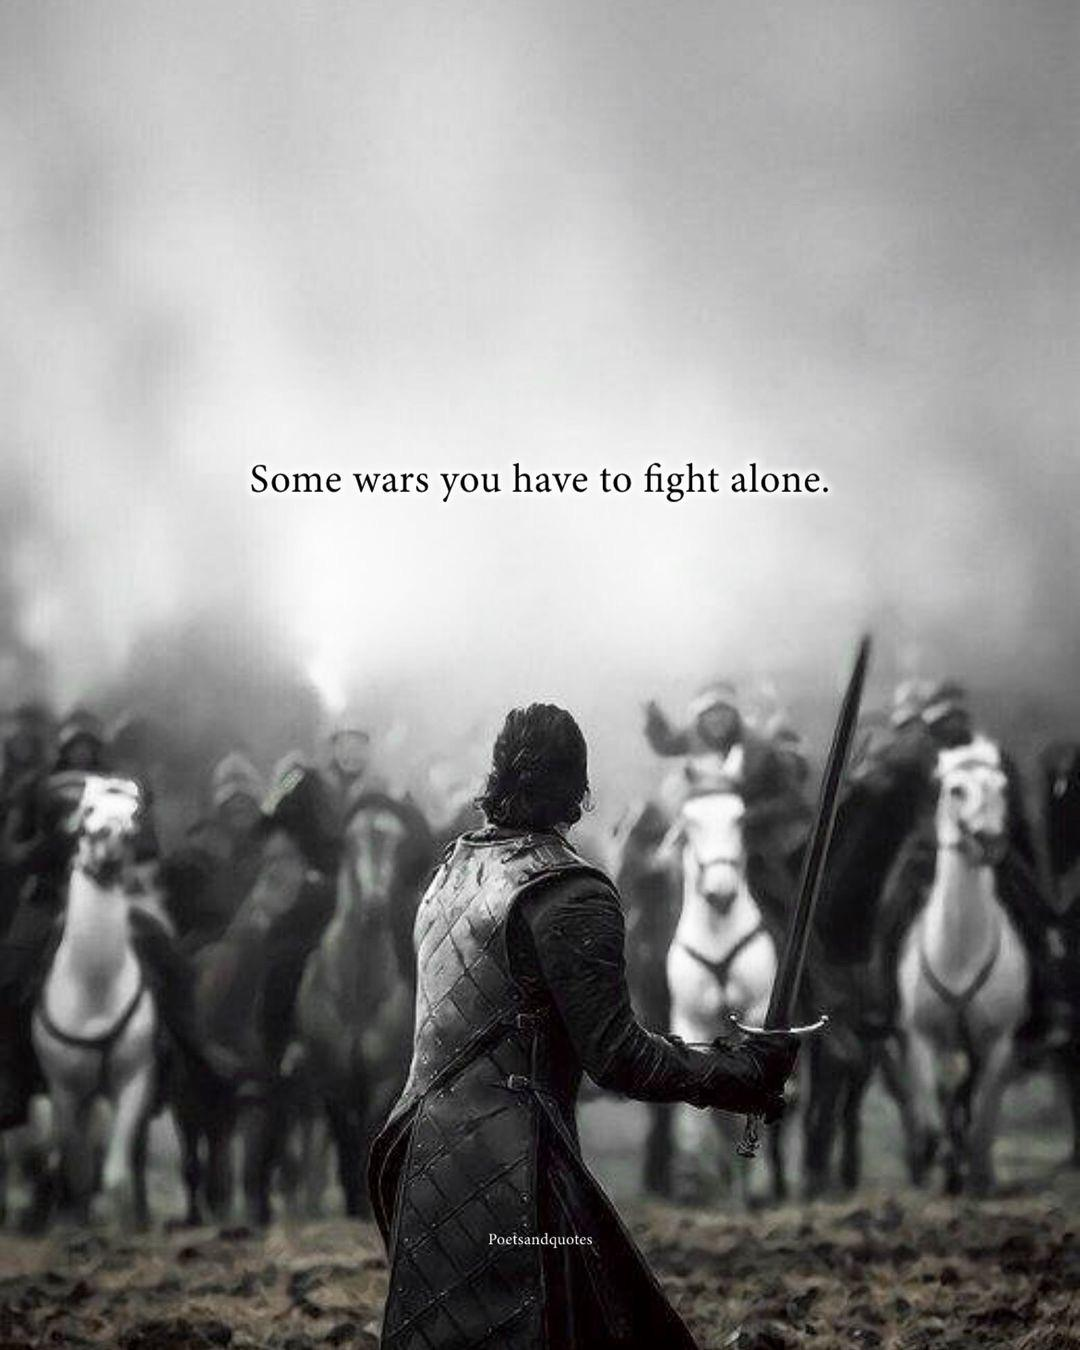

In [ ]:
# Load and display the second Game of Thrones image
image_2 = Image.open("/content/GOT_2.jpeg")
image_2

In [ ]:
# Ask Gemini to read all visible text from the image
prompt_4 = "Read all the text written in the image"

response_4 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[image_2, prompt_4]  # Provide the image and the OCR-style prompt
)

# Print the extracted text from the image
print(response_4.text)

Here's all the text I can read in the image:

1.  **Some wars you have to fight alone.**
2.  **Poetsandquotes**


In [ ]:
# Ask Gemini to identify differences between the two images
prompt_5 = "What is the difference between both the images"

response_5 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[image_1, image_2, prompt_5] # Provide both images and the comparison prompt
)

# Print the model's analysis of differences between the images
print(response_5.text)

The two images are very similar in their core visual content, showing Jon Snow from Game of Thrones facing an approaching cavalry. However, there are several key differences:

1.  **Color vs. Monochrome:**
    *   **Image 1:** Is in **full color**, preserving the original cinematic look of the scene with its natural hues (dark armor, white horses, muddy ground, etc.).
    *   **Image 2:** Is in **black and white (or monochrome/greyscale)**. This gives it a more dramatic, somber, or timeless feel.

2.  **Text Overlay:**
    *   **Image 1:** Has **no text** on it.
    *   **Image 2:** Features a prominent **text overlay** at the top that reads: "Some wars you have to fight alone."

3.  **Watermark/Logo:**
    *   **Image 1:** Has **no visible watermark or logo**.
    *   **Image 2:** Includes a small **watermark/logo** at the bottom center that says "Poetsandquotes".

In summary, Image 1 is a direct still from the source material, while Image 2 is an edited version designed to convey a s

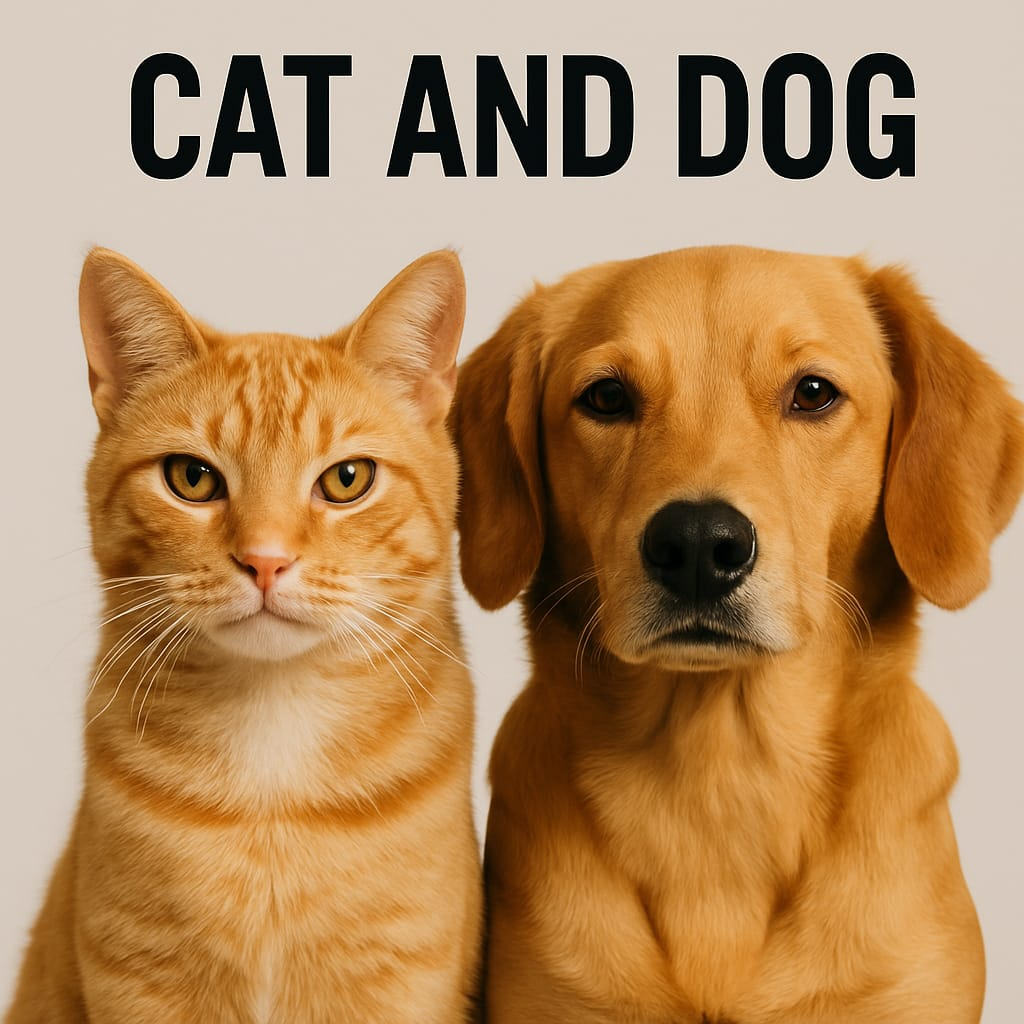

In [ ]:
# Load and display the third image (cat and dog)
image_3 = Image.open("/content/cat_dog_1.jpg")
image_3

In [ ]:
# Get and display the width and height of the third image
w,h = image_3.size
w,h

(1024, 1024)

In [21]:
# Ask Gemini to detect all main objects in the image and return their bounding boxes in JSON format
prompt_6 = """Find all main objects in the image,
              For each object, return JSON:
              {"label":".....","box_2d":[ymin, xmin, ymax, xmax]}scaled to 0-100
"""

response_6 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[image_3, prompt_6]  # Provide the image and the object detection prompt
)

# Print the JSON response containing detected objects and their bounding boxes
print(response_6.text)

```json
[
  {"label": "text", "box_2d": [4, 11, 18, 89]},
  {"label": "cat", "box_2d": [21, 0, 100, 49]},
  {"label": "dog", "box_2d": [21, 50, 100, 100]}
]
```


In [ ]:
# Ask Gemini Pro to analyze the image and return all main elements (people, objects, animals, plants, text) with scaled bounding boxes in JSON format
prompt_7 = """
Analyze the given image and detect all main elements.

Rules:

1. For people:
   - Return the exact name if recognizable.
   - If unknown, return "unknown".
   - Do not output duplicates for the same person.

2. For objects, animals, plants, or text:
   - Return descriptive labels (e.g., "rose", "chair", "dog", "tree").
   - Avoid generic labels like "main objects".
   - Do not output duplicates for the same object.

3. Return only valid JSON array (no text, no markdown).
4. Bounding boxes must be scaled 0–100: [ymin, xmin, ymax, xmax].
5. Include all visible main elements, even if there are multiple of the same type.

Output format:

[
  {"label": "Person Name or unknown", "box_2d": [ymin, xmin, ymax, xmax]},
  {"label": "object/animal/plant/text", "box_2d": [ymin, xmin, ymax, xmax]},
  ...
]
"""

response_7 = client.models.generate_content(
    model='gemini-2.5-pro',
    contents=[image_3, prompt_7],
    config={"response_mime_type":"application/json"}  # Ensure the output is valid JSON
)

# Print the JSON response containing all detected elements and their bounding boxes
print(response_7.text)

[
  {"box_2d": [43, 126, 185, 895], "label": "text"},
  {"box_2d": [229, 437, 1000, 1000], "label": "dog"},
  {"box_2d": [226, 0, 1000, 502], "label": "cat"}
]


In [ ]:
# Parse the JSON response from Gemini Pro into a Python object and display it
obj = json.loads(response_7.text)
obj

[{'box_2d': [43, 126, 185, 895], 'label': 'text'},
 {'box_2d': [229, 437, 1000, 1000], 'label': 'dog'},
 {'box_2d': [226, 0, 1000, 502], 'label': 'cat'}]

In [ ]:
# Prepare the image for drawing by creating a canvas and loading the default font for labels
draw = ImageDraw.Draw(image_3) # Create a drawing canvas on the image
font = ImageFont.load_default() # Load default font for labeling detected objects

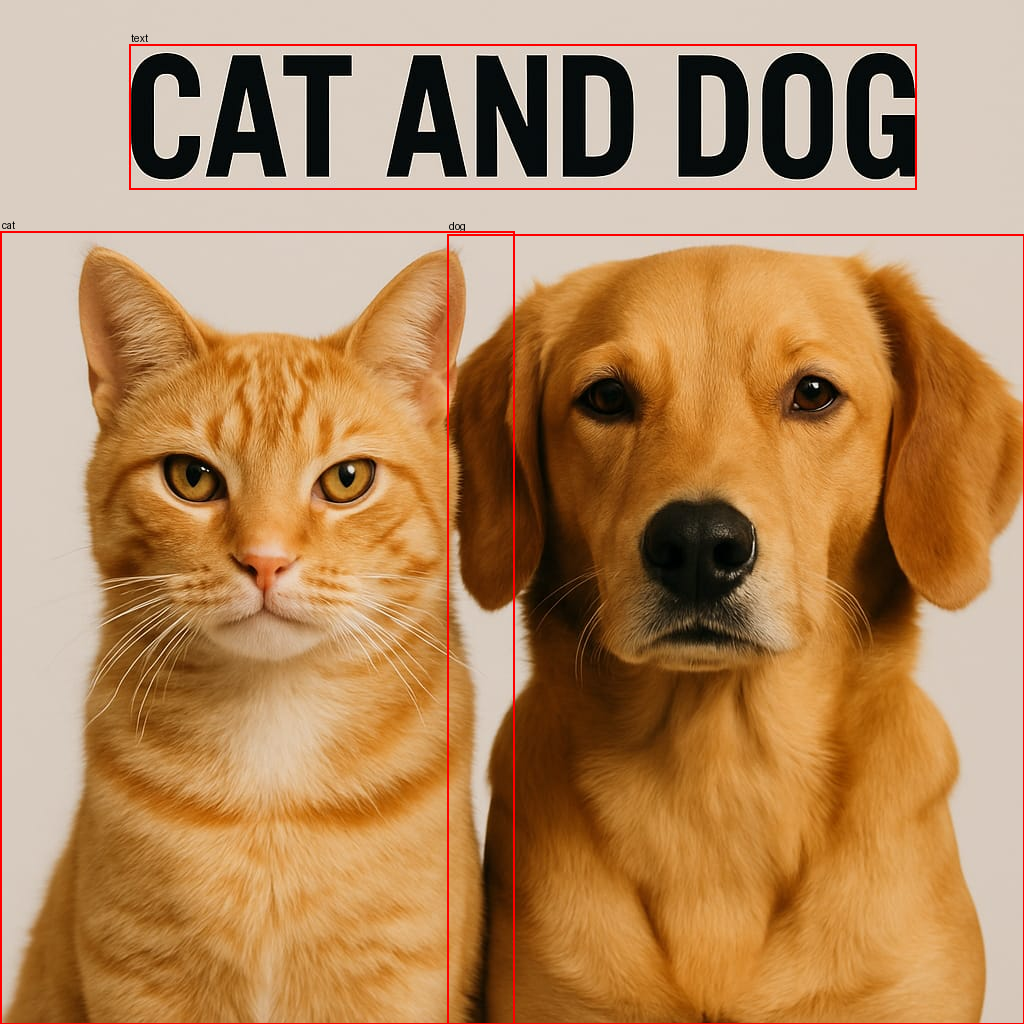

In [ ]:
# Draw bounding boxes and labels for each detected object on the image and display it
for i in obj:
  label = i["label"]
  ymin, xmin, ymax, xmax = i["box_2d"]

  # Scale the bounding boxes to actual image dimensions
  x1, y1 = int(xmin/1000*w), int(ymin/1000*h)
  x2, y2 = int(xmax/1000*w), int(ymax/1000*h)

  # Draw rectangle around the object
  draw.rectangle([x1, y1, x2, y2], outline="Red", width=2)

  # Draw the label above the rectangle
  tw, th = draw.textbbox((0, 0), label, font=font)[2:]
  draw.text((x1 + 2, y1 - th - 2), label, fill="black", font=font)

# Display the annotated image
display(image_3)